<a href="https://colab.research.google.com/github/Shrushti88/Machine-Vision/blob/main/CM23006_MV0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WIN_20260623_10_48_15_Pro.jpg to WIN_20260623_10_48_15_Pro.jpg


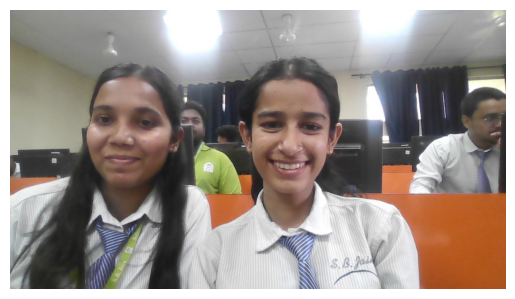

In [3]:
img = cv2.imread(next(iter(uploaded)))

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [4]:
print("Shape :", img.shape)
print("Height :", img.shape[0])
print("Width :", img.shape[1])
print("Channels :", img.shape[2])
print("Data Type :", img.dtype)

Shape : (720, 1280, 3)
Height : 720
Width : 1280
Channels : 3
Data Type : uint8


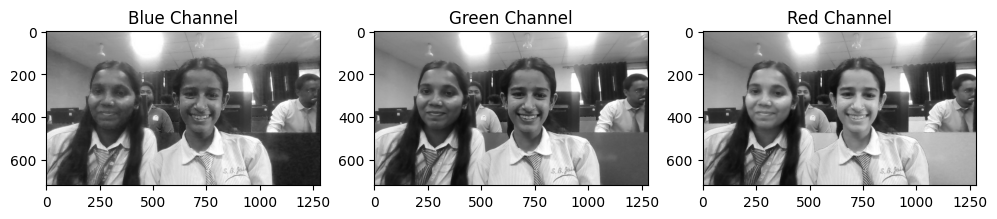

In [5]:
blue = img[:,:,0]
green = img[:,:,1]
red = img[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(blue, cmap='gray')
plt.title("Blue Channel")

plt.subplot(1,3,2)
plt.imshow(green, cmap='gray')
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(red, cmap='gray')
plt.title("Red Channel")

plt.show()

In [6]:
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Javascript, display

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);
      document.body.appendChild(div);

      const video = document.createElement('video');
      video.style.display = 'block';
      document.body.appendChild(video);

      const stream = await navigator.mediaDevices.getUserMedia({video:true});
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video,0,0);

      stream.getTracks()[0].stop();
      div.remove();
      video.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

<IPython.core.display.Javascript object>

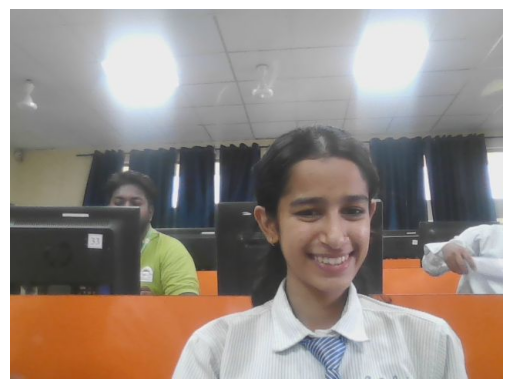

In [8]:
filename = take_photo()

img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [9]:
video = cv2.VideoCapture("sample.mp4")

while True:
    ret, frame = video.read()
    if not ret:
        break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame)
    plt.axis('off')
    plt.show()
    break      # Shows first frame only

video.release()